# Zero-DCE++ with SE-Block — v4

## What was wrong in v3 and what changed

**v3 problem:** `L_tv_enh` (weight=500) caused **mode collapse to black images**.
The model found that outputting all-black pixels minimises 4 of 5 losses simultaneously
(`L_tv_enh`, `L_tv_alpha`, `L_spa`, `L_col`), while `L_exp` (weight=10) was too weak
to fight back. Result: PSNR ~8 dB, SSIM ~0.001, completely black output.

| Change | v3 | v4 | Reason |
|---|---|---|---|
| `L_tv_enh` | weight=500 | **REMOVED** | Direct cause of black collapse |
| Exposure loss | global MAE | **per-patch MSE** | Harder to fool, stronger signal |
| Exposure weight | 10 | **20** | Extra protection against collapse |
| Noise fix | `L_tv_enh` | **bilateral filter** at inference only | Correct place for it |
| Aspect-ratio resize | ✅ kept | ✅ kept | Still fixes blocky colour |
| Early stopping | ✅ kept | ✅ kept | Still useful |
| Gradient accumulation | ✅ kept | ✅ kept | Still smooths curve |


## v5 — DPED-style hybrid addition (on top of v4)

**What's added:** two extra loss terms computed against the LOL-v2 **paired ground-truth**
image (`batch['normal']`), which the dataset already loads but v4 never used during training
(only `batch['low']` was used). No architecture change, no discriminator, **one optimizer** —
same training loop shape as v4, just two more terms in the loss sum.

| Term | What it does | Needs |
|---|---|---|
| `DPEDColorLoss` | Gaussian-blurs both images, then MSE — matches overall color/tone | `batch['normal']` |
| `VGGContentLoss` | Frozen VGG-19 perceptual loss — matches structure/content | `batch['normal']` |

```
L_total = L_spa + 20·L_exp + 5·L_col + 1600·L_tv_alpha + 10·L_dped_color + 1·L_content
                  \_____________ v4, zero-reference ____________/   \____ v5, paired ____/
```

The adversarial/texture term from DPED (which needs a discriminator + a second optimizer)
is intentionally **left out** here to keep training stable and the loop simple, per the
earlier decision to prioritize a single-optimizer setup while you start testing.


### 1. Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: NVIDIA GeForce RTX 3060


### 2. SE-Block

In [2]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

print('SE-Block defined')


SE-Block defined


### 3. DCENet

In [3]:
class DCENet(nn.Module):
    def __init__(self, use_attention=True):
        super().__init__()
        self.use_attention = use_attention
        self.conv1 = nn.Conv2d(3,  32, 3, 1, 1)
        self.conv2 = nn.Conv2d(32, 32, 3, 1, 1)
        self.conv3 = nn.Conv2d(32, 32, 3, 1, 1)
        if use_attention:
            self.se = SEBlock(32, reduction=8)
        self.conv4 = nn.Conv2d(32, 32, 3, 1, 1)
        self.conv5 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv6 = nn.Conv2d(64, 32, 3, 1, 1)
        self.conv7 = nn.Conv2d(64, 24, 3, 1, 1)
        self.relu  = nn.ReLU(inplace=True)
        nn.init.normal_(self.conv7.weight, mean=0, std=0.01)
        nn.init.constant_(self.conv7.bias, 0)

    def forward(self, x):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))
        if self.use_attention:
            x3 = self.se(x3)
        x4 = self.relu(self.conv4(x3))
        x5 = self.relu(self.conv5(torch.cat([x4, x3], 1)))
        x6 = self.relu(self.conv6(torch.cat([x5, x2], 1)))
        return torch.tanh(self.conv7(torch.cat([x6, x1], 1)))

def enhance_image_with_curves(x, alpha):
    enhanced = x.clone()
    for i in range(8):
        a_i = alpha[:, i*3:(i+1)*3, :, :]
        enhanced = enhanced + a_i * enhanced * (1 - enhanced)
    return torch.clamp(enhanced, 0, 1)

model = DCENet(use_attention=True).to(device)
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')


Model: 79,672 parameters


### 4. Loss Function — v4 (L_tv_enh removed, exposure upgraded)

**Why `L_tv_enh` was removed:**  
A smoothness penalty on the enhanced image has the same minimum as a black image —
zero gradients everywhere. Combined with L_spa and L_col also preferring flat output,
the model collapses. Noise is handled by bilateral filter at inference instead.

**Why exposure loss is upgraded to per-patch MSE:**  
The old `torch.abs(mean - 0.6)` computed ONE number for the whole image.
The model could satisfy it with a bimodal image (some very bright + some very dark patches
averaging to 0.6). Per-patch MSE forces **every 16×16 patch** to be near 0.6 independently.

```
L_total = L_spa + 20·L_exp + 5·L_col + 1600·L_tv_alpha
```


In [4]:
class ZeroDCELoss(nn.Module):
    """
    v4 loss — back to 4 terms, exposure upgraded.

    L_total = L_spa + 20*L_exp + 5*L_col + 1600*L_tv_alpha

    Changes vs v3:
      - L_tv_enh REMOVED (was causing mode collapse to black)
      - L_exp: global MAE -> per-patch MSE (stronger, harder to fool)
      - L_exp weight: 10 -> 20 (extra protection against collapse)
    """
    def __init__(self, E=0.6, patch_size=16):
        super().__init__()
        self.E          = E
        self.patch_size = patch_size

    def forward(self, enhanced, low, alpha):
        enh_g = 0.299*enhanced[:,0:1] + 0.587*enhanced[:,1:2] + 0.114*enhanced[:,2:3]
        low_g = 0.299*low[:,0:1]      + 0.587*low[:,1:2]      + 0.114*low[:,2:3]

        L_spa      = self._spatial_loss(enh_g, low_g)
        L_exp      = self._exposure_loss(enh_g)       # per-patch MSE
        L_col      = self._color_loss(enhanced)
        L_tv_alpha = self._tv_loss(alpha)

        total = L_spa + 20*L_exp + 5*L_col + 1600*L_tv_alpha
        return total, L_spa, L_exp, L_col, L_tv_alpha

    def _spatial_loss(self, enh, low):
        enh_d = F.avg_pool2d(enh, 4)
        low_d = F.avg_pool2d(low, 4)
        d_el = enh_d[:,:,:,1:] - enh_d[:,:,:,:-1];  d_ll = low_d[:,:,:,1:] - low_d[:,:,:,:-1]
        d_er = enh_d[:,:,:,:-1]- enh_d[:,:,:,1:];   d_lr = low_d[:,:,:,:-1]- low_d[:,:,:,1:]
        d_eu = enh_d[:,:,1:,:] - enh_d[:,:,:-1,:];  d_lu = low_d[:,:,1:,:] - low_d[:,:,:-1,:]
        d_ed = enh_d[:,:,:-1,:]- enh_d[:,:,1:,:];   d_ld = low_d[:,:,:-1,:]- low_d[:,:,1:,:]
        return (torch.mean((d_el-d_ll)**2) + torch.mean((d_er-d_lr)**2) +
                torch.mean((d_eu-d_lu)**2) + torch.mean((d_ed-d_ld)**2))

    def _exposure_loss(self, img):
        """
        Per-patch MSE exposure loss.
        Forces EVERY 16x16 patch (not just the global mean) to be near E=0.6.
        Much harder for the model to fool than a single global mean.
        """
        patches = F.avg_pool2d(img, self.patch_size)
        return torch.mean((patches - self.E) ** 2)

    def _color_loss(self, img):
        mr = torch.mean(img[:,0])
        mg = torch.mean(img[:,1])
        mb = torch.mean(img[:,2])
        return torch.abs(mr-mg) + torch.abs(mg-mb) + torch.abs(mb-mr)

    def _tv_loss(self, alpha):
        return (torch.mean(torch.abs(alpha[:,:,:,:-1] - alpha[:,:,:,1:])) +
                torch.mean(torch.abs(alpha[:,:,:-1,:] - alpha[:,:,1:,:])))

loss_fn = ZeroDCELoss(E=0.6, patch_size=16).to(device)
print('Loss function defined')
print('  L_total = L_spa + 20*L_exp(per-patch MSE) + 5*L_col + 1600*L_tv_alpha')


Loss function defined
  L_total = L_spa + 20*L_exp(per-patch MSE) + 5*L_col + 1600*L_tv_alpha


### 4b. DPED-style Hybrid Losses (v5 addition)

Both losses below are **paired** — they compare the enhanced output directly against
the LOL-v2 `normal` ground-truth image, unlike the four `ZeroDCELoss` terms above which
never look at `normal` at all.


In [5]:
class DPEDColorLoss(nn.Module):
    """
    DPED-style color loss (Ignatov et al., 2017).
    Gaussian-blur both images heavily, then MSE. Blurring washes out texture,
    so what's left is basically 'did we get the color/tone right'.
    """
    def __init__(self, kernel_size=21, sigma=3):
        super().__init__()
        coords = torch.arange(kernel_size, dtype=torch.float32) - kernel_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        kernel_2d = (g[:, None] * g[None, :]).expand(3, 1, kernel_size, kernel_size).contiguous()
        self.register_buffer('kernel', kernel_2d)
        self.pad = kernel_size // 2

    def _blur(self, x):
        return F.conv2d(x, self.kernel, padding=self.pad, groups=3)

    def forward(self, enhanced, target):
        return F.mse_loss(self._blur(enhanced), self._blur(target))


class VGGContentLoss(nn.Module):
    """Perceptual loss using a frozen, pretrained VGG-19 (relu4_4 features)."""
    def __init__(self):
        super().__init__()
        import torchvision.models as models
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.feature_extractor = nn.Sequential(*list(vgg.children())[:27]).eval()  # up to relu4_4
        for p in self.feature_extractor.parameters():
            p.requires_grad = False
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def _normalize(self, x):
        return (x - self.mean) / self.std

    def forward(self, enhanced, target):
        f_enh = self.feature_extractor(self._normalize(enhanced))
        f_tgt = self.feature_extractor(self._normalize(target))
        return F.mse_loss(f_enh, f_tgt.detach())

color_loss_fn   = DPEDColorLoss(kernel_size=21, sigma=3).to(device)
content_loss_fn = VGGContentLoss().to(device)
print('DPED-style hybrid losses defined: DPEDColorLoss + VGGContentLoss')

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\faiz/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [01:53<00:00, 5.08MB/s] 


DPED-style hybrid losses defined: DPEDColorLoss + VGGContentLoss


### 5. Dataset — aspect-ratio-preserving resize (from v3, kept)

Short side scaled to `resize_size`, then random crop. Prevents the 400×600→614×614 squash that caused blocky colour.


In [6]:
class LOLDataset(Dataset):
    def __init__(self, image_pairs, img_size=512, augment=False):
        self.image_pairs = image_pairs
        self.img_size    = img_size
        self.augment     = augment
        self.resize_size = int(img_size * 1.15)

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img    = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')

        # Resize by SHORT SIDE — preserves aspect ratio
        low_img    = TF.resize(low_img,    self.resize_size, interpolation=Image.BILINEAR)
        normal_img = TF.resize(normal_img, self.resize_size, interpolation=Image.BILINEAR)

        if self.augment:
            i, j, h, w = transforms.RandomCrop.get_params(
                low_img, (self.img_size, self.img_size))
            low_img    = TF.crop(low_img,    i, j, h, w)
            normal_img = TF.crop(normal_img, i, j, h, w)
            if torch.rand(1) > 0.5:
                low_img    = TF.hflip(low_img)
                normal_img = TF.hflip(normal_img)
        else:
            low_img    = TF.center_crop(low_img,    self.img_size)
            normal_img = TF.center_crop(normal_img, self.img_size)

        return {
            'low':      TF.to_tensor(low_img),
            'normal':   TF.to_tensor(normal_img),
            'filename': pair['filename']
        }

def load_image_pairs(data_path):
    low_p  = data_path / 'Low'
    norm_p = data_path / 'Normal'
    lows   = sorted([f for f in os.listdir(low_p)  if f.endswith(('.jpg','.png'))])
    norms  = sorted([f for f in os.listdir(norm_p) if f.endswith(('.jpg','.png'))])
    assert len(lows)==len(norms), f'Pair mismatch: {len(lows)} vs {len(norms)}'
    return [{'low':str(low_p/l),'normal':str(norm_p/n),'filename':l}
            for l,n in zip(lows,norms)]

BASE_PATH    = Path('LOL-v2')
train_pairs  = load_image_pairs(BASE_PATH / 'Real_captured' / 'Train')
test_pairs   = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')
print(f'LOL-v2: {len(train_pairs)} train, {len(test_pairs)} test')

BATCH_SIZE  = 8
IMG_SIZE    = 512
train_loader = DataLoader(LOLDataset(train_pairs, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(LOLDataset(test_pairs,  IMG_SIZE, augment=False),
                          batch_size=1,          shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')


LOL-v2: 689 train, 100 test
Train batches: 87 | Test batches: 100


### 6. Training — Early stopping + gradient accumulation (from v3, kept)

**Collapse guard:** Every 10 epochs, the mean brightness of one batch is checked.
If it drops below 0.1 (near-black), training stops immediately with a warning
rather than wasting time on a collapsed run.


In [7]:
LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 1e-4
NUM_EPOCHS      = 200
PATIENCE        = 25
ACCUM_STEPS     = 4
CHECKPOINT      = 'best_zerodce_seblock_v5_hybrid.pth'

# New hybrid loss weights. Start small relative to the existing v4 scale
# (L_exp is already weighted 20x and L_tv_alpha 1600x) and tune up from here
# once you confirm training is stable.
WEIGHT_DPED_COLOR = 10
WEIGHT_CONTENT    = 1

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

history = {'loss':[],'spa':[],'exp':[],'col':[],'tv_a':[],'dped_color':[],'content':[],'lr':[]}
best_loss    = float('inf')
no_improve   = 0
stopped_epoch = NUM_EPOCHS

print(f"{'='*60}")
print(f'TRAINING v5 (Zero-DCE++ + DPED-style hybrid) — max {NUM_EPOCHS} epochs, patience={PATIENCE}')
print(f'Effective batch: {BATCH_SIZE}\u00d7{ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}')
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS):
    model.train()
    totals = dict(loss=0, spa=0, exp=0, col=0, tv_a=0, dped_color=0, content=0)

    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'[{epoch+1}/{NUM_EPOCHS}]')

    for step, batch in pbar:
        low_imgs    = batch['low'].to(device)
        normal_imgs = batch['normal'].to(device)   # LOL-v2 ground truth (already in the dataset)

        alpha    = model(low_imgs)
        enhanced = enhance_image_with_curves(low_imgs, alpha)

        # v4 zero-reference losses (unchanged)
        loss, L_spa, L_exp, L_col, L_tv_a = loss_fn(enhanced, low_imgs, alpha)

        # v5 additions: DPED-style paired losses against the LOL-v2 ground truth
        L_dped_color = color_loss_fn(enhanced, normal_imgs)
        L_content    = content_loss_fn(enhanced, normal_imgs)

        loss = loss + WEIGHT_DPED_COLOR * L_dped_color + WEIGHT_CONTENT * L_content

        (loss / ACCUM_STEPS).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            optimizer.step()
            optimizer.zero_grad()

        totals['loss']       += loss.item()
        totals['spa']        += L_spa.item()
        totals['exp']        += L_exp.item()
        totals['col']        += L_col.item()
        totals['tv_a']       += L_tv_a.item()
        totals['dped_color'] += L_dped_color.item()
        totals['content']    += L_content.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'exp':  f'{L_exp.item():.4f}',
                          'd_col': f'{L_dped_color.item():.4f}',
                          'cont': f'{L_content.item():.4f}'})

    n = len(train_loader)
    avg_loss = totals['loss'] / n
    for k in ['loss','spa','exp','col','tv_a','dped_color','content']:
        history[k].append(totals[k] / n)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # \u2500\u2500 Collapse guard: check mean brightness every 10 epochs \u2500\u2500\u2500\u2500\u2500
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            sample = next(iter(train_loader))['low'].to(device)
            a_s    = model(sample)
            e_s    = enhance_image_with_curves(sample, a_s)
            mean_brightness = e_s.mean().item()
        model.train()
        print(f'  [Epoch {epoch+1}] mean_brightness={mean_brightness:.4f}', end='')
        if mean_brightness < 0.1:
            print(' \u2014 COLLAPSE DETECTED, stopping!')
            stopped_epoch = epoch + 1
            break
        else:
            print(f' | no_improve={no_improve}/{PATIENCE}')

    # \u2500\u2500 Early stopping \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  Epoch {epoch+1}: loss={avg_loss:.6f}  [BEST saved]')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            stopped_epoch = epoch + 1
            print(f'  Early stopping at epoch {stopped_epoch}')
            break

    scheduler.step()

print(f"\n{'='*60}")
print(f'DONE \u2014 best loss: {best_loss:.6f} | stopped at epoch: {stopped_epoch}')
print(f"{'='*60}")

TRAINING v5 (Zero-DCE++ + DPED-style hybrid) — max 200 epochs, patience=25
Effective batch: 8×4 = 32


[1/200]: 100%|██████████| 87/87 [02:10<00:00,  1.50s/it, loss=10.4885, exp=0.3314, d_col=0.2091, cont=0.8574]


  Epoch 1: loss=10.469924  [BEST saved]


[2/200]: 100%|██████████| 87/87 [01:28<00:00,  1.01s/it, loss=10.1293, exp=0.3149, d_col=0.1658, cont=1.2100]


  Epoch 2: loss=9.464521  [BEST saved]


...

  [Epoch 60] mean_brightness=0.4130 | no_improve=6/25


[70/200]: 100%|██████████| 87/87 [01:27<00:00,  1.01s/it, loss=5.9425, exp=0.1644, d_col=0.0456, cont=0.9282]


  [Epoch 70] mean_brightness=0.5276 | no_improve=16/25


[78/200]: 100%|██████████| 87/87 [01:27<00:00,  1.01s/it, loss=2.1865, exp=0.0080, d_col=0.0348, cont=0.1338]

  Early stopping at epoch 78

DONE — best loss: 3.200441 | stopped at epoch: 78


### 7. Training Curves

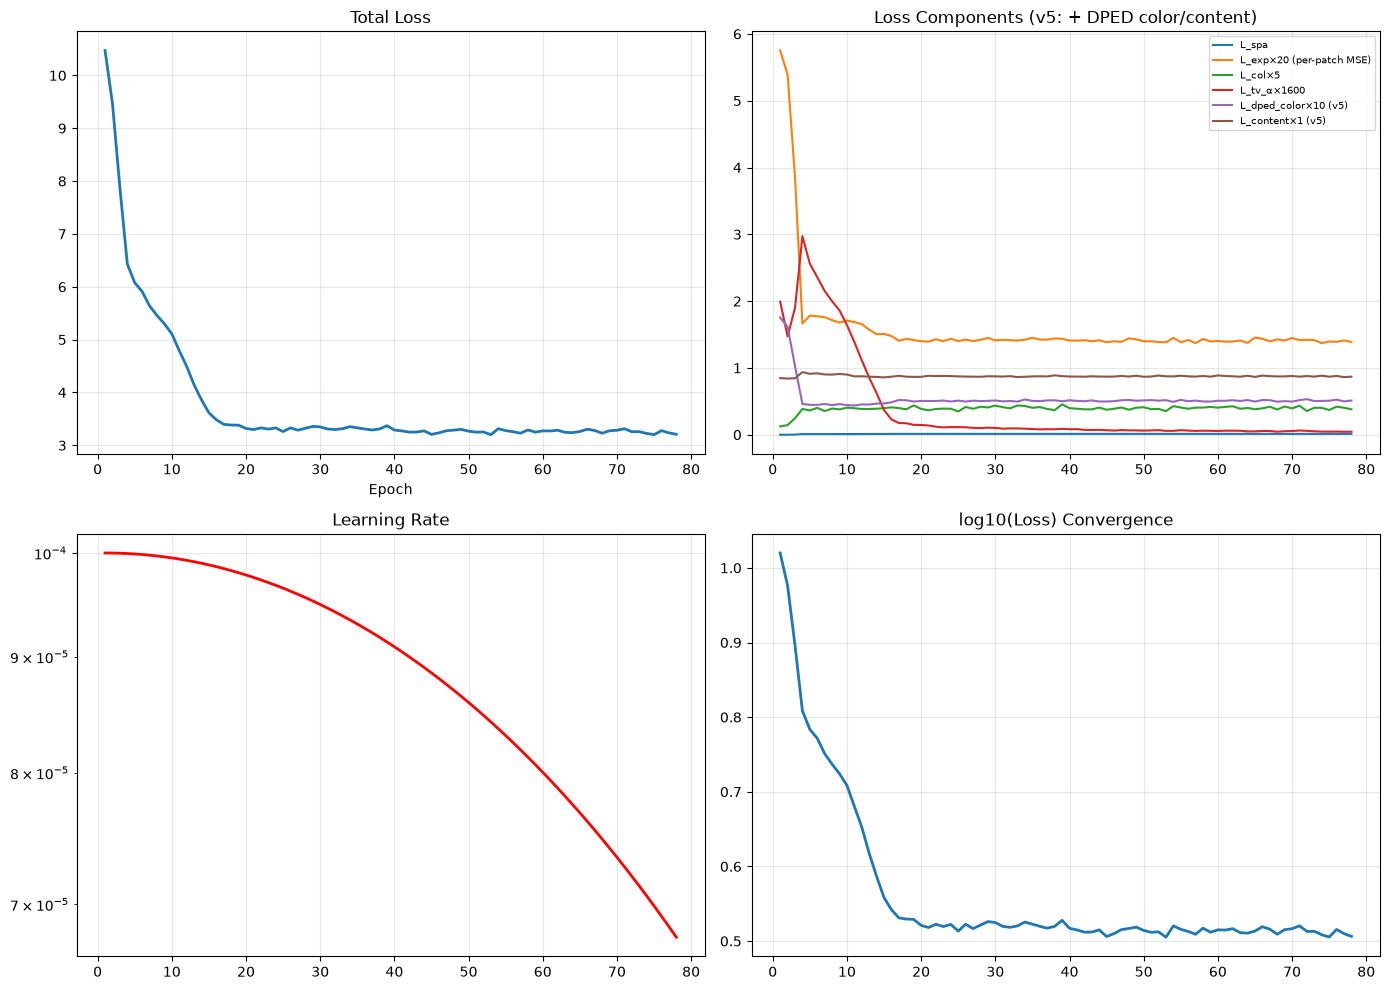

Saved: training_history_v5.png


In [8]:
ep = range(1, len(history['loss'])+1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ep, history['loss'], linewidth=2)
axes[0,0].set_title('Total Loss'); axes[0,0].set_xlabel('Epoch')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ep, history['spa'],                        label='L_spa')
axes[0,1].plot(ep, np.array(history['exp'])*20,           label='L_exp\u00d720 (per-patch MSE)')
axes[0,1].plot(ep, np.array(history['col'])*5,            label='L_col\u00d75')
axes[0,1].plot(ep, np.array(history['tv_a'])*1600,        label='L_tv_\u03b1\u00d71600')
axes[0,1].plot(ep, np.array(history['dped_color'])*10,    label='L_dped_color\u00d710 (v5)')
axes[0,1].plot(ep, np.array(history['content'])*1,        label='L_content\u00d71 (v5)')
axes[0,1].set_title('Loss Components (v5: + DPED color/content)')
axes[0,1].legend(fontsize=7); axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(ep, history['lr'], color='red', linewidth=2)
axes[1,0].set_title('Learning Rate'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, np.log10(np.array(history['loss'])+1e-8), linewidth=2)
axes[1,1].set_title('log10(Loss) Convergence'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_v5.png', dpi=150)
plt.show()
print('Saved: training_history_v5.png')

### 8. Inference — bilateral filter for real-world photos

Noise is handled HERE (at inference), not during training.
Use `denoise=True` for your own real-world photos, `denoise=False` for metric evaluation.


In [ ]:

def enhance_single_image(image_path, checkpoint=CHECKPOINT,
                          denoise=True, d=9, sigma_color=75, sigma_space=75):
    m = DCENet(use_attention=True).to(device)
    m.load_state_dict(torch.load(checkpoint, map_location=device))
    m.eval()

    img = Image.open(image_path).convert('RGB')
    inp = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        enh = enhance_image_with_curves(inp, m(inp))

    enh_np = (enh.squeeze(0).cpu().permute(1,2,0).numpy()*255).astype(np.uint8)

    if denoise:
        bgr    = cv2.cvtColor(enh_np, cv2.COLOR_RGB2BGR)
        bgr    = cv2.bilateralFilter(bgr, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        enh_np = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(np.array(img)); axes[0].set_title('Input (low-light)');  axes[0].axis('off')
    axes[1].imshow(enh_np);        axes[1].set_title('Enhanced v4' + (' + Bilateral' if denoise else ''))
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('inference_v4.png', dpi=150)
    plt.show()
    return enh_np

print('Usage:')
print('  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos')
print('  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation')


Usage:
  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos
  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation


---
### Version History

| Version | Key issue | Status |
|---|---|---|
| v1 (original) | `tanh*0.15`, wrong loss weights, broken pairing | Fixed in v2 |
| v2 | Working baseline | Good |
| v3 | `L_tv_enh` weight=500 \u2192 mode collapse to black | **Broken** |
| v4 | `L_tv_enh` removed, exposure upgraded to per-patch MSE, collapse guard added | Good |
| **v5** | Added DPED-style `DPEDColorLoss` + `VGGContentLoss` against LOL-v2 ground truth, single optimizer, no discriminator | **Current** |
